## Time series

##### Data Ingestion
##### EDA of the data
##### Processing of the data
##### Model Training
##### Model Evalution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import sys

In [4]:
data =pd.read_csv('tesla.csv')
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock_Splits
0,2020-01-01,232.36,235.54,228.07,233.10,55784489,0,0.0
1,2020-01-02,405.21,413.57,401.13,411.04,105573844,0,0.0
2,2020-01-03,339.60,352.76,325.96,332.67,118862335,0,0.0
3,2020-01-06,299.60,310.72,295.48,305.00,80034404,0,0.0
4,2020-01-07,166.81,179.01,162.37,171.88,58640858,0,0.0


In [7]:
stock_data =data[['Date','Close']]
stock_data

,Date,Close
0,2020-01-01,233.10
1,2020-01-02,411.04
2,2020-01-03,332.67
3,2020-01-06,305.00
4,2020-01-07,171.88
...,...,...
995,2023-10-25,144.62
996,2023-10-26,398.14
997,2023-10-27,158.62
998,2023-10-30,403.56


In [8]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1000 non-null   object 
 1   Close   1000 non-null   float64
dtypes: float64(1), object(1)
memory usage: 15.8+ KB


In [9]:
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

C:\Users\abhay\AppData\Local\Temp\ipykernel_13428\3223796615.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data['Date'] = pd.to_datetime(stock_data['Date'])


In [10]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1000 non-null   datetime64[ns]
 1   Close   1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.8 KB


In [12]:
stock_data.head(2)

,Date,Close
0,2020-01-01,233.10
1,2020-01-02,411.04


##### Why we are converting date column to index
##### 1) Easily retrive data
##### 2) Visualization is easy
##### 3) Those Library has been design in such wayit requied date column as index

In [13]:
stock_data = stock_data.set_index('Date')

In [14]:
stock_data

,Close
Date,
2020-01-01,233.10
2020-01-02,411.04
2020-01-03,332.67
2020-01-06,305.00
2020-01-07,171.88
...,...
2023-10-25,144.62
2023-10-26,398.14
2023-10-27,158.62


In [ ]:
# EDA 


### EDA

In [15]:
stock_data.describe()

,Close
count,1000.000000
mean,266.936400
std,87.696111
min,113.560000
25%,189.930000
50%,269.535000
75%,341.542500
max,424.860000


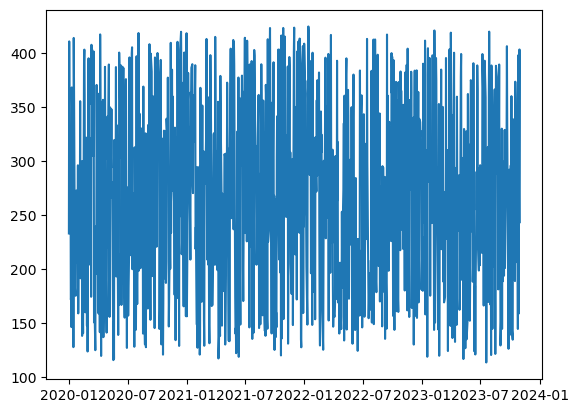

In [27]:
plt.plot(stock_data)

(array([ 82., 132.,  94., 103.,  87., 118., 107.,  90., 100.,  87.]),
 array([113.56, 144.69, 175.82, 206.95, 238.08, 269.21, 300.34, 331.47,
        362.6 , 393.73, 424.86]),
 <BarContainer object of 10 artists>)

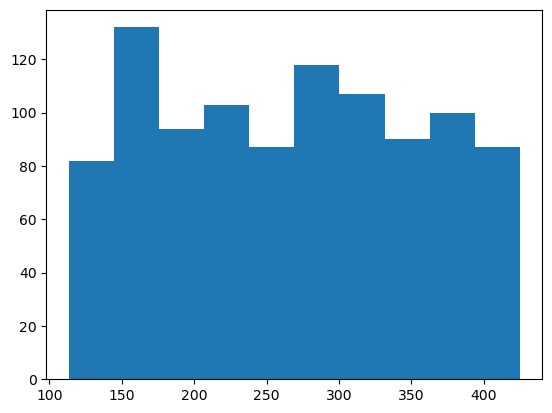

In [17]:
plt.hist(stock_data.Close)

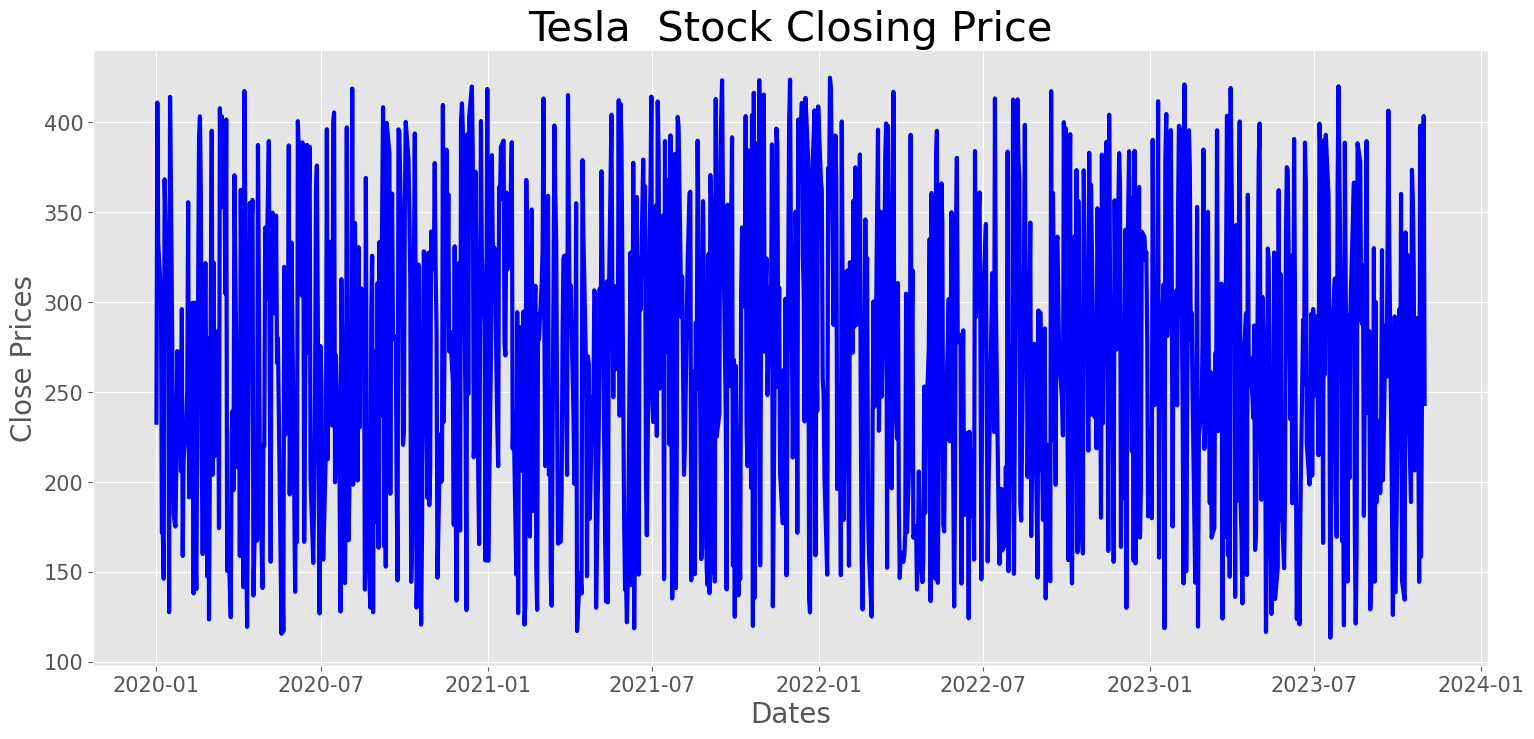

In [28]:
# plotting close price
plt.style.use('ggplot')
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel('Dates',fontsize = 20)
plt.xticks(fontsize = 15)
plt.ylabel('Close Prices',fontsize = 20)
plt.yticks(fontsize = 15)
plt.plot(stock_data['Close'],linewidth = 3, color = 'blue')
plt.title ('Tesla  Stock Closing Price', fontsize = 30)
plt.show()

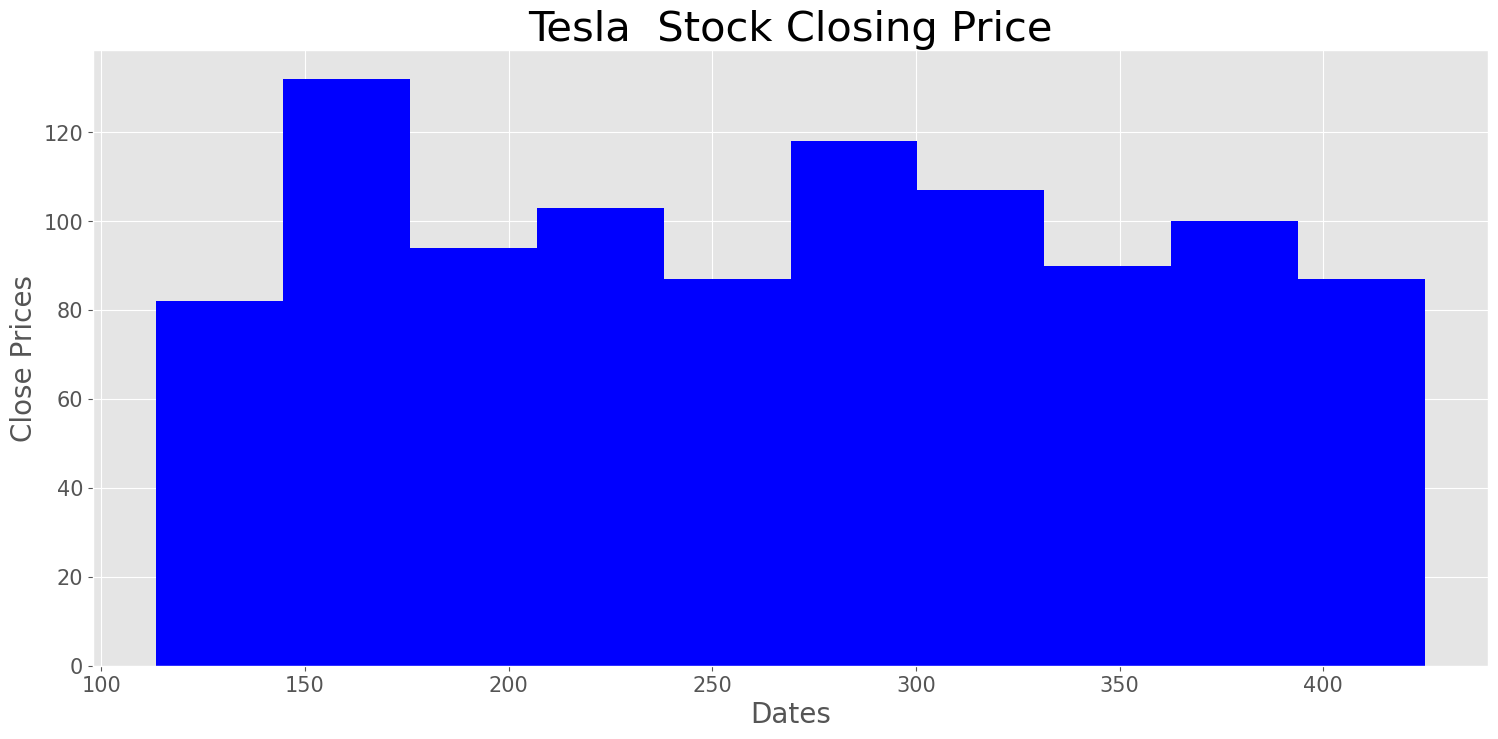

In [29]:
# plotting close price
plt.style.use('ggplot')
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel('Dates',fontsize = 20)
plt.xticks(fontsize = 15)
plt.ylabel('Close Prices',fontsize = 20)
plt.yticks(fontsize = 15)
plt.hist(stock_data['Close'],linewidth = 3, color = 'blue')
plt.title ('Tesla  Stock Closing Price', fontsize = 30)
plt.show()

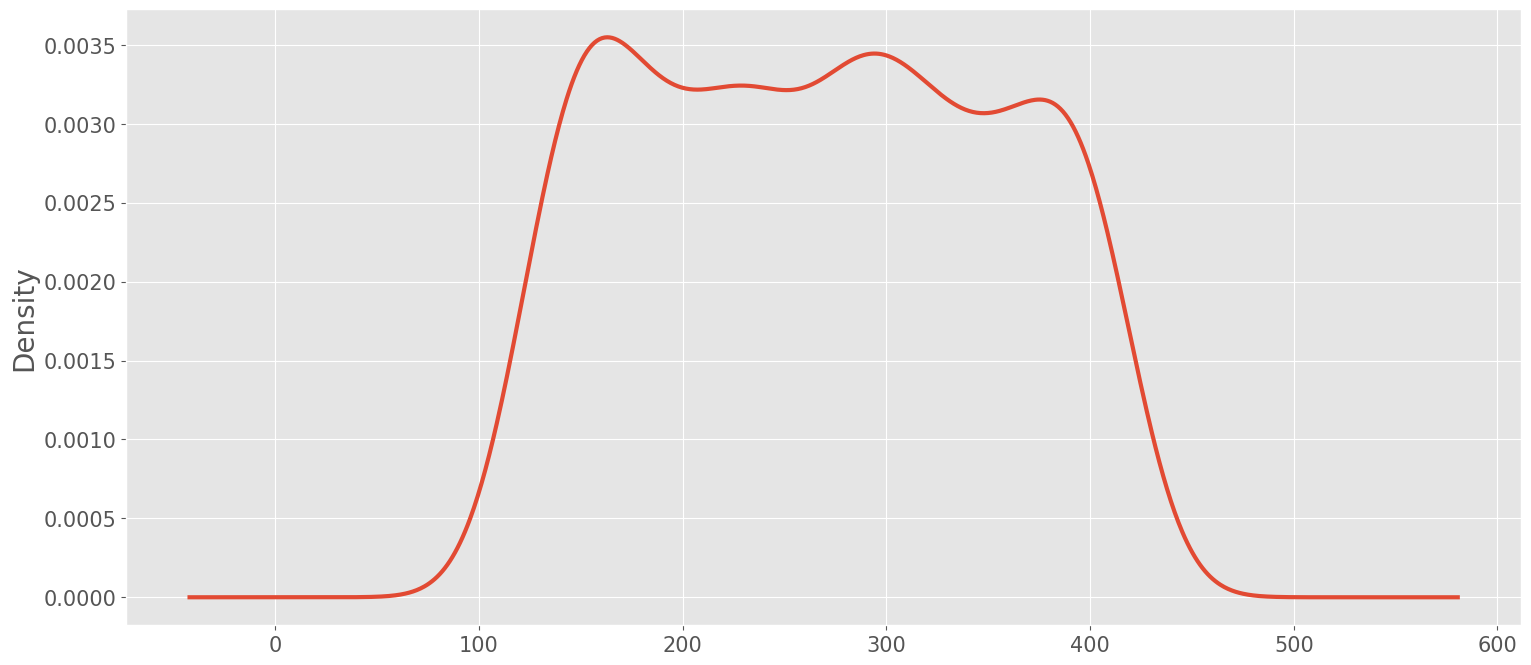

In [30]:
df_close = stock_data['Close']
df_close.plot(kind='kde',figsize=(18,8), linewidth = 3)
plt.xticks(fontsize = 15)
plt.grid('both')
plt.ylabel('Density', fontsize = 20)
plt.yticks(fontsize = 15)
plt.show()

In [42]:
rolmean =stock_data['Close'].rolling(45).mean()
rolmean

Date
2020-01-01           NaN
2020-01-02           NaN
2020-01-03           NaN
2020-01-06           NaN
2020-01-07           NaN
                 ...    
2023-10-25    253.018222
2023-10-26    254.735778
2023-10-27    254.232444
2023-10-30    254.542222
2023-10-31    254.654889
Name: Close, Length: 1000, dtype: float64

In [37]:
rolstd =stock_data['Close'].rolling(45).std()
rolstd

Date
2020-01-01          NaN
2020-01-02          NaN
2020-01-03          NaN
2020-01-06          NaN
2020-01-07          NaN
                ...    
2023-10-25    77.530788
2023-10-26    79.887911
2023-10-27    80.430810
2023-10-30    80.989011
2023-10-31    80.969640
Name: Close, Length: 1000, dtype: float64

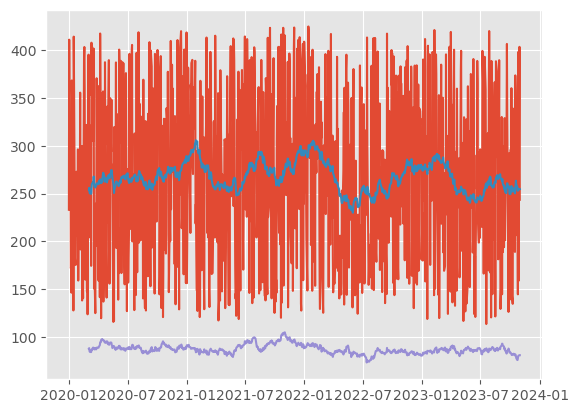

In [44]:
plt.plot(stock_data.Close)
plt.plot(rolmean)
plt.plot(rolstd)

In [45]:
from statsmodels.tsa.stattools import adfuller
adft = adfuller(stock_data['Close'])

In [51]:
pd.Series(adft[0:4], index = ['test_stats','p-value','lag','data points'])

test_stats     -30.536747
p-value          0.000000
lag              0.000000
data points    999.000000
dtype: float64

In [58]:
def test_stationarity (timeseries):
    # Determing rolling statistics
    rolmean = timeseries.rolling(45).mean() # rolling mean
    rolstd = timeseries.rolling(45).std()  #rolling standard deviation
    
    # plot rolling statistics:
    plt.figure(figsize=(18,8))
    plt.grid('both')
    plt.plot(timeseries, color = 'blue', label = 'Original', linewidth = 3)
    plt.plot(rolmean, color = 'red', label = 'Rolling mean', linewidth = 3)
    plt.plot(rolstd, color = 'black', label = 'Rolling Std', linewidth = 4)
    plt.legend(loc = 'best',fontsize = 20, shadow = True, facecolor = 'lightpink', edgecolor = 'k')
    plt.title('Rolling Mean and Standard Deviation', fontsize = 25)
    plt.xticks(fontsize = 15)
    plt.yticks(fontsize = 15)
    plt.show(block=False)
    print('Result of dickey fuller test')
    adft = adfuller(timeseries, autolag='AIC')

    # Output for dft will give us without defining what the values are.
    # hence we manually write what walues does it ecplains using for loop

    output = pd.Series(adft[0:4], index = ['Test Statistics','p-value','No. of lags used','Number of observations used'])
    for key , values in adft[4].items():
        output['Critical values (%s)' %key] = values
    print(output)


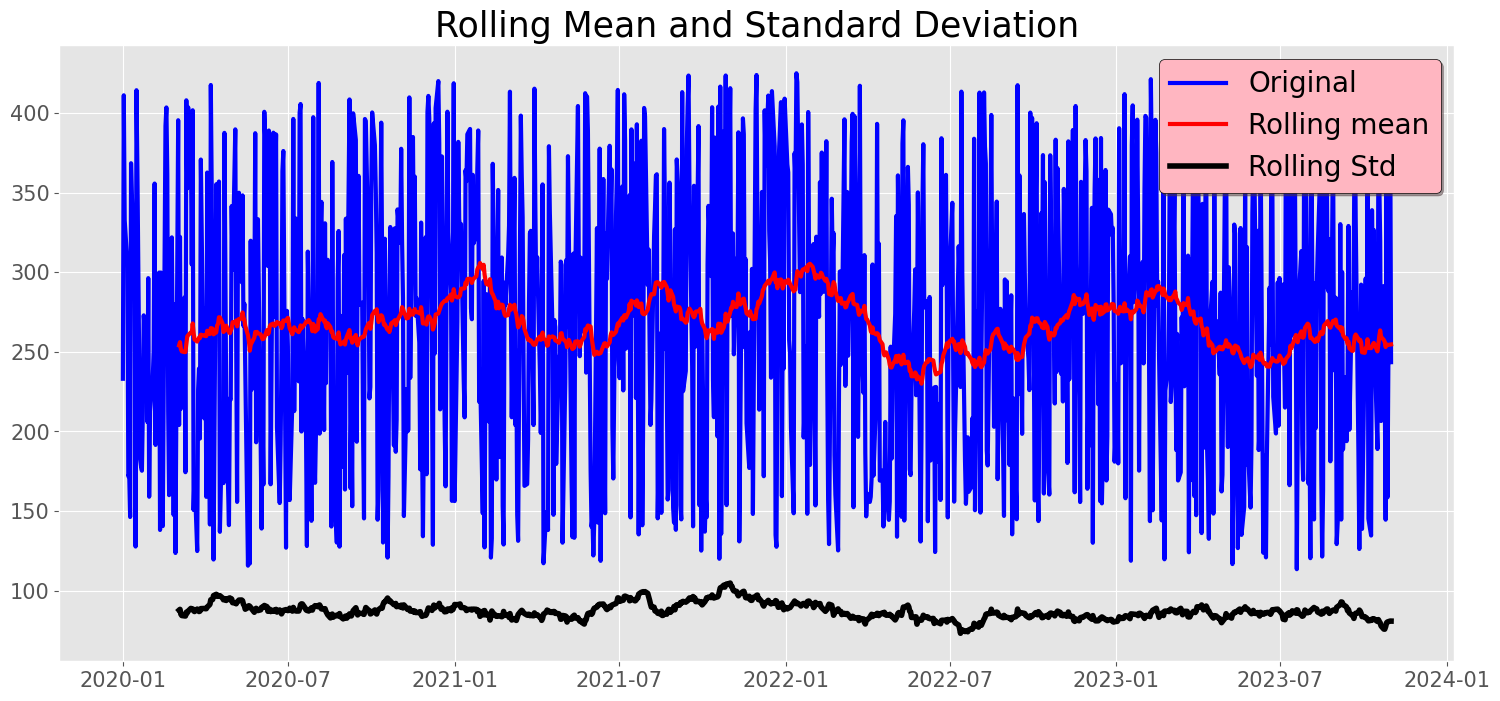

Result of dickey fuller test
Test Statistics                -30.536747
p-value                          0.000000
No. of lags used                 0.000000
Number of observations used    999.000000
Critical values (1%)            -3.436913
Critical values (5%)            -2.864437
Critical values (10%)           -2.568313
dtype: float64


In [59]:
test_stationarity(stock_data.Close)

In [60]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(stock_data[['Close']], period=12)

In [61]:
result.seasonal

Date
2020-01-01    -1.716063
2020-01-02     9.731752
2020-01-03   -15.481281
2020-01-06    12.495848
2020-01-07    -9.946093
                ...    
2023-10-25    -0.361434
2023-10-26    -1.716063
2023-10-27     9.731752
2023-10-30   -15.481281
2023-10-31    12.495848
Name: seasonal, Length: 1000, dtype: float64

<Figure size 2000x1000 with 0 Axes>

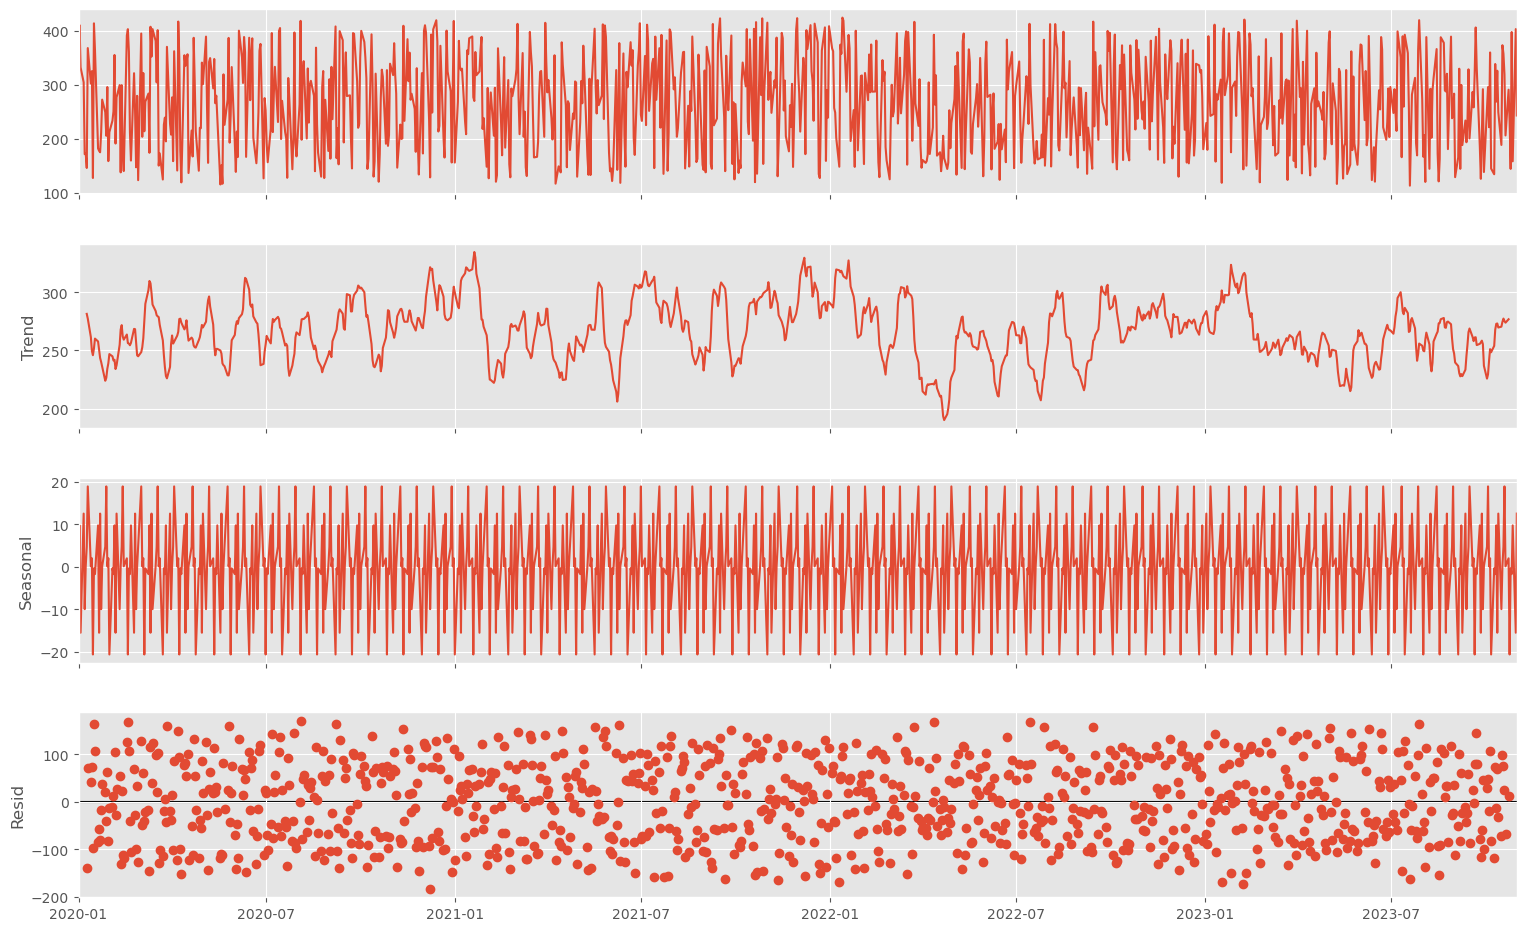

In [62]:
fig = plt.figure(figsize = (20,10))
fig = result.plot()
fig.set_size_inches(17,10)

In [63]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(stock_data[['Close']], period=12, model='multiplicative')

<Figure size 2000x1000 with 0 Axes>

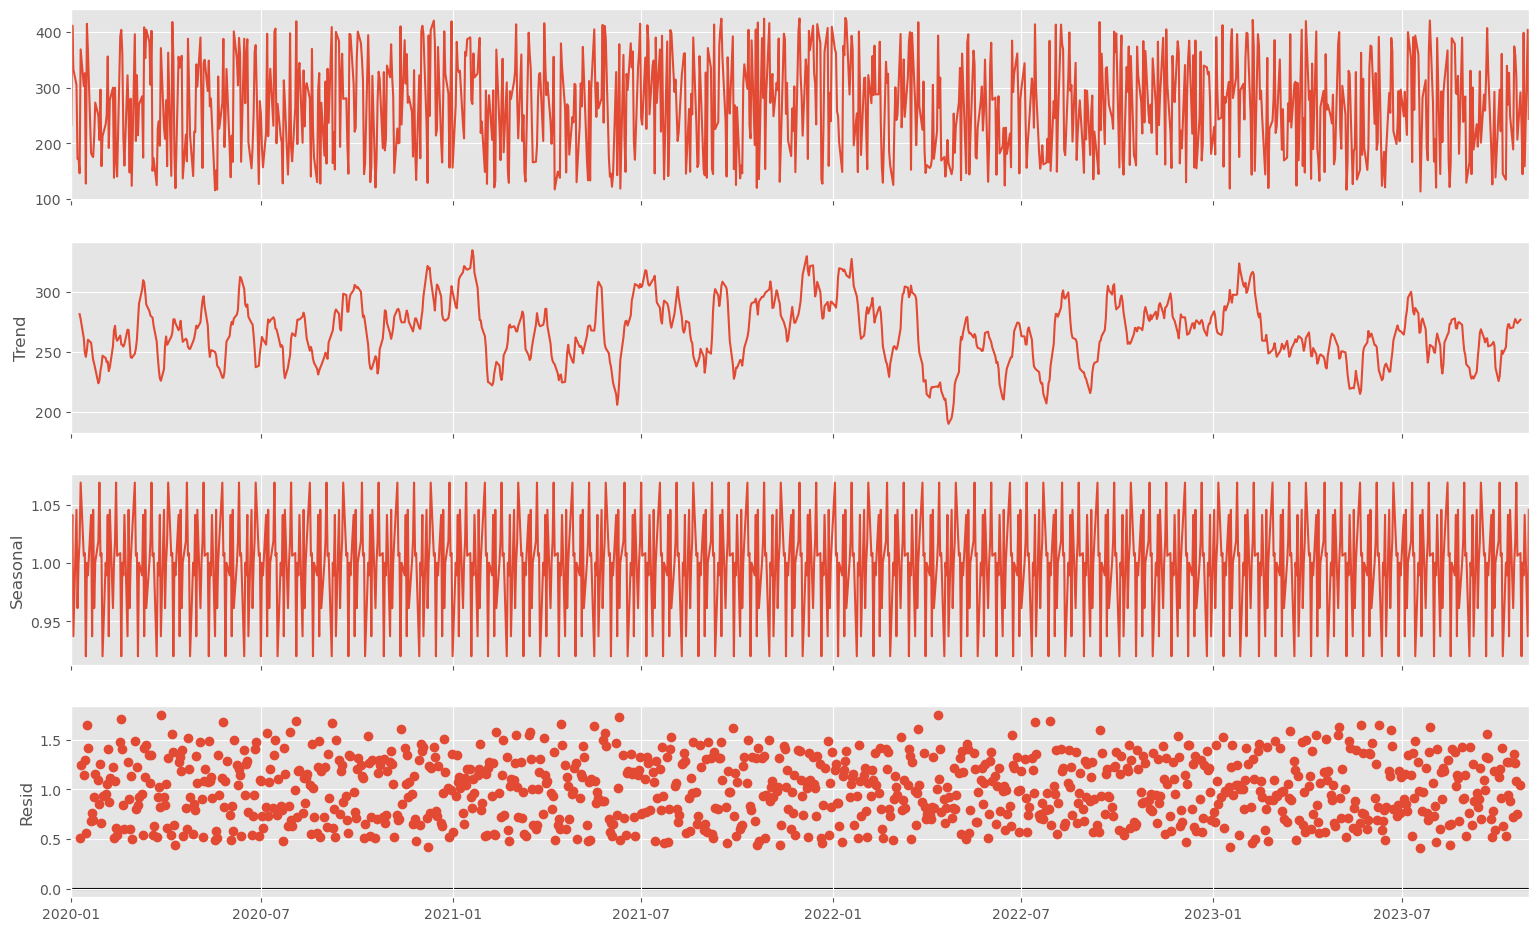

In [64]:
fig = plt.figure(figsize = (20,10))
fig = result.plot()
fig.set_size_inches(17,10)

<Axes: ylabel='Close'>

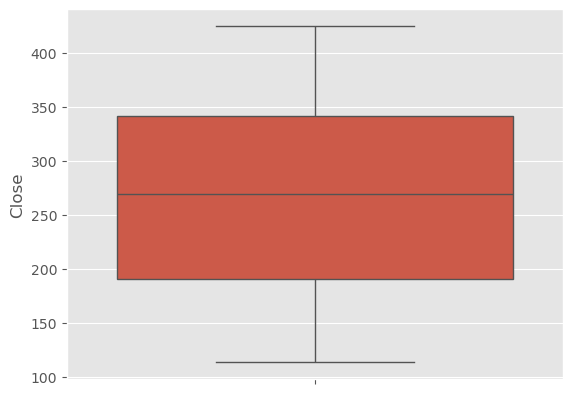

In [65]:
import seaborn as sns
sns.boxplot(stock_data.Close)

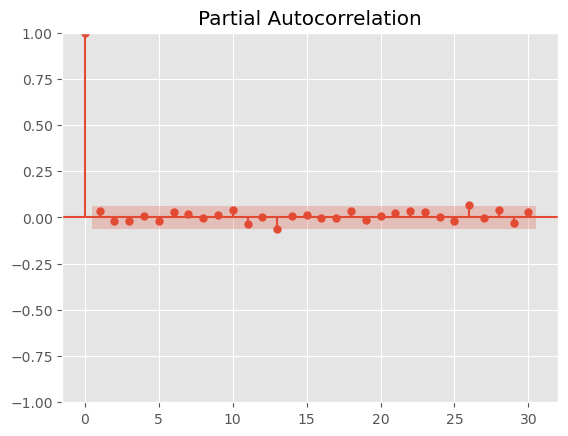

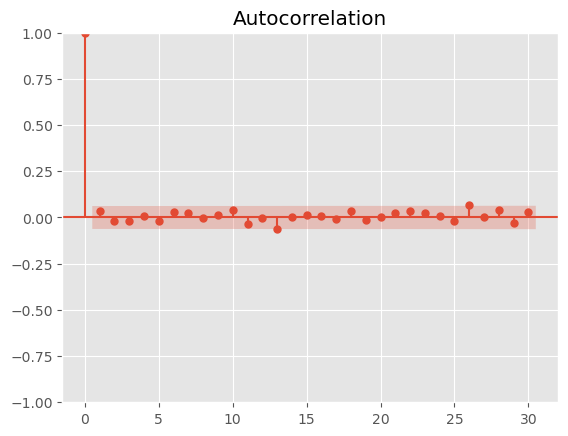

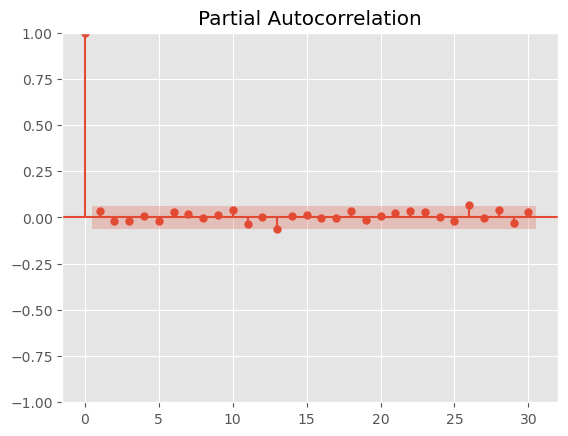

In [66]:
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf
plot_acf(stock_data.Close)
plot_pacf(stock_data.Close)

### Convert Non Stationary to Stationary

In [67]:
df_close =stock_data['Close']
df_close

Date
2020-01-01    233.10
2020-01-02    411.04
2020-01-03    332.67
2020-01-06    305.00
2020-01-07    171.88
               ...  
2023-10-25    144.62
2023-10-26    398.14
2023-10-27    158.62
2023-10-30    403.56
2023-10-31    243.52
Name: Close, Length: 1000, dtype: float64

In [72]:
df_close = df_close.diff()

In [74]:
df_close = df_close.dropna()
df_close

Date
2020-01-02    177.94
2020-01-03    -78.37
2020-01-06    -27.67
2020-01-07   -133.12
2020-01-08      1.37
               ...  
2023-10-25    -88.06
2023-10-26    253.52
2023-10-27   -239.52
2023-10-30    244.94
2023-10-31   -160.04
Name: Close, Length: 999, dtype: float64

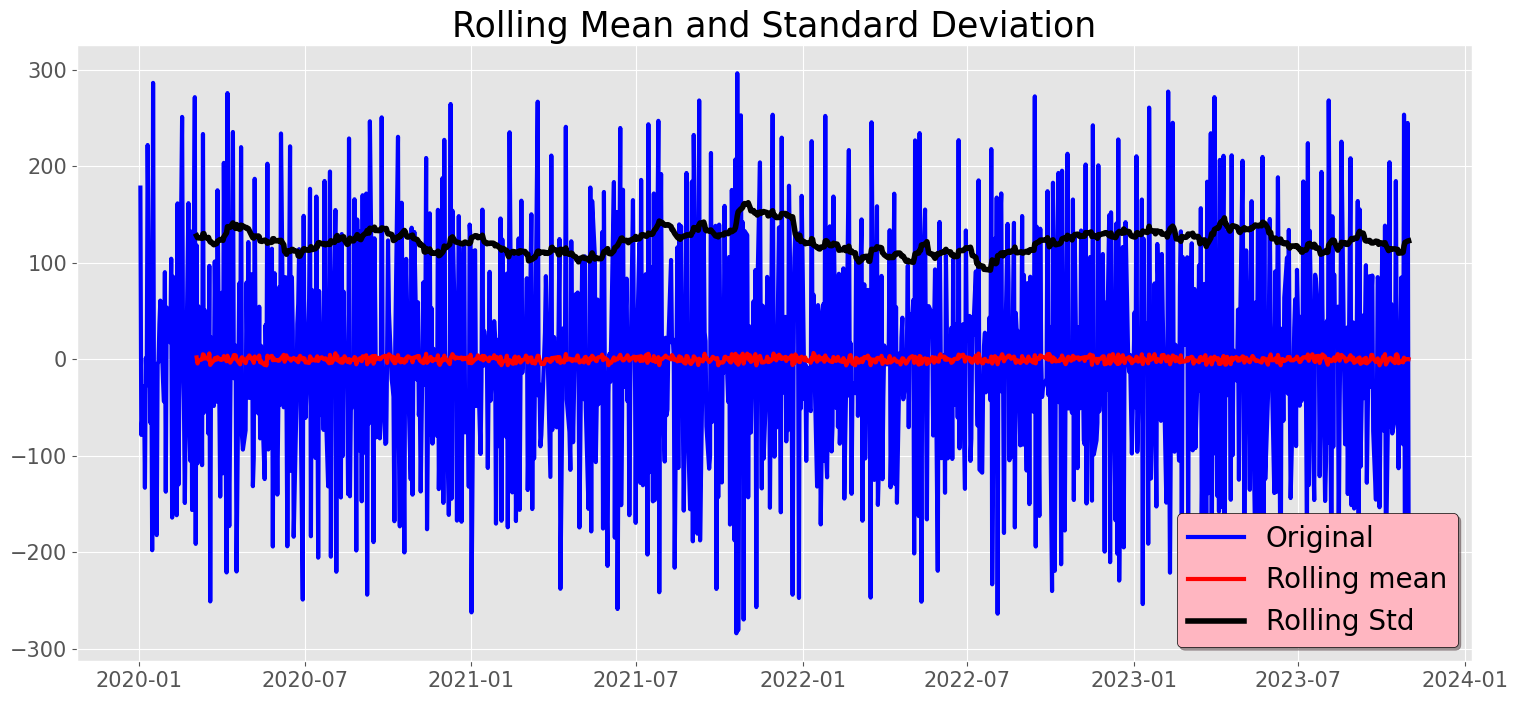

Result of dickey fuller test
Test Statistics               -1.229034e+01
p-value                        7.853140e-23
No. of lags used               2.100000e+01
Number of observations used    9.770000e+02
Critical values (1%)          -3.437061e+00
Critical values (5%)          -2.864503e+00
Critical values (10%)         -2.568348e+00
dtype: float64


In [76]:
test_stationarity(df_close)

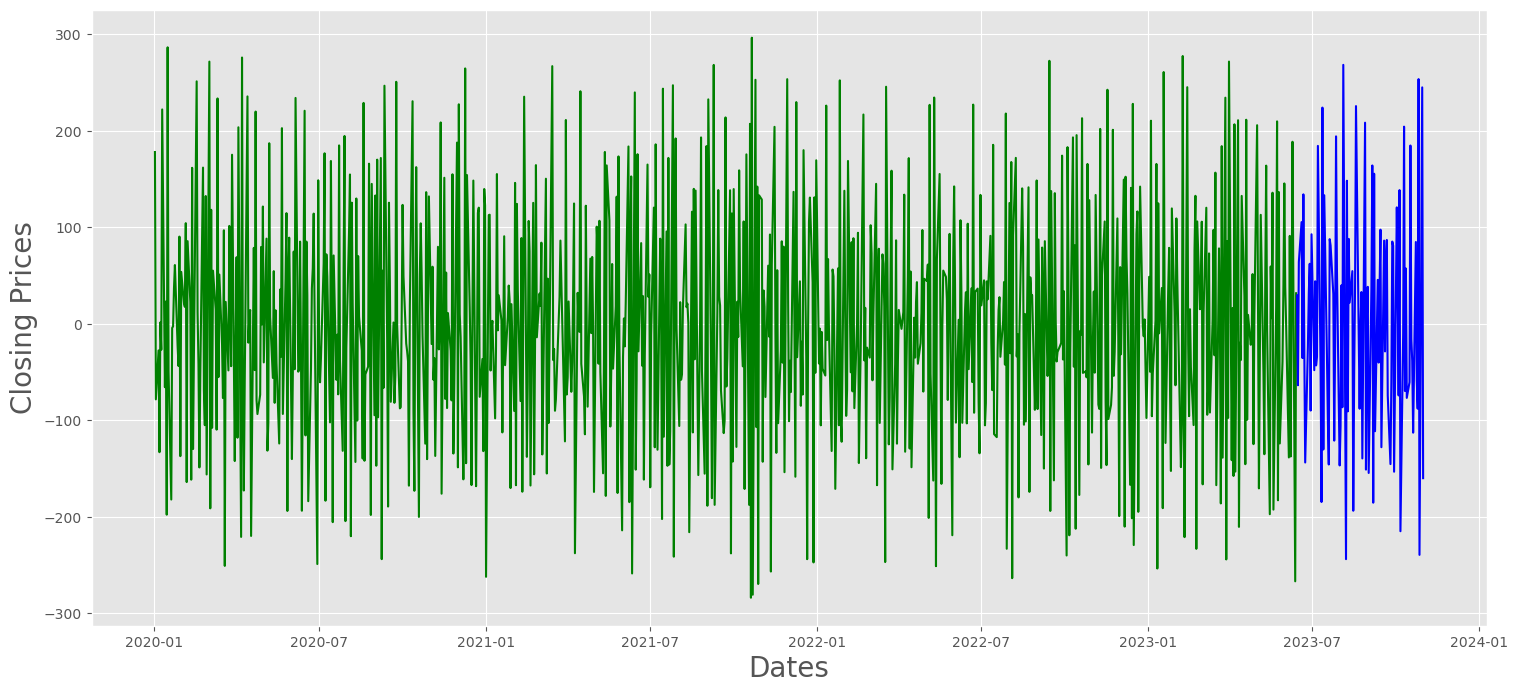

In [85]:
train_data = df_close[0:-100]
test_data  =df_close[-100:]
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel('Dates', fontsize = 20)
plt.ylabel('Closing Prices', fontsize = 20)
plt.plot(train_data, 'green', label = 'train Data')
plt.plot(test_data, 'blue', label = 'Test Data')


### Model Building

In [86]:
import statsmodels.api  as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [87]:
history = [x for x in train_data]

In [88]:
history

[177.94000000000003,
 -78.37,
 -27.670000000000016,
 -133.12,
 1.3700000000000045,
 -26.930000000000007,
 222.07,
 -65.75999999999999,
 23.00999999999999,
 -197.87,
 286.46000000000004,
 -49.60000000000002,
 -182.18,
 -4.349999999999994,
 -2.7299999999999898,
 36.71000000000001,
 60.819999999999965,
 -23.139999999999986,
 -43.79999999999998,
 90.29999999999998,
 -137.22,
 53.70000000000002,
 21.17999999999998,
 17.5,
 104.22,
 -164.07999999999998,
 85.61000000000001,
 22.609999999999957,
 -161.59999999999997,
 161.58999999999997,
 -129.83999999999997,
 -29.330000000000013,
 251.19000000000003,
 11.620000000000005,
 -41.99000000000001,
 -148.92000000000002,
 -52.46000000000001,
 161.81000000000003,
 -69.16000000000003,
 -105.12,
 132.35000000000002,
 -156.19,
 271.65,
 -191.29999999999998,
 118.08000000000001,
 -107.86000000000001,
 54.97999999999996,
 14.900000000000034,
 -109.75,
 233.46999999999997,
 -55.31,
 50.93000000000001,
 -21.71999999999997,
 -77.0,
 96.84999999999997,
 -250.9

In [91]:
model = ARIMA(history, order=(1,1,1))

In [92]:
model = model.fit()

In [94]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  899
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -5481.796
Date:                Mon, 20 Jul 2026   AIC                          10969.592
Time:                        10:31:31   BIC                          10983.992
Sample:                             0   HQIC                         10975.094
                                - 899                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4705      0.035    -13.385      0.000      -0.539      -0.402
ma.L1         -0.9999      1.207     -0.828      0.408      -3.366       1.366
sigma2      1.164e+04   1.42e+04      0.821      0.412   -1.62e+04    3.94e+04
===================================================================================
Ljung-Box (L1) (Q):                  21.08   Jarque-Bera (JB):                16.73
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.97   Skew:                             0.09
Prob(H) (two-sided):                  0.81   Kurtosis:                         2.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [95]:
model.forecast()[0]

np.float64(-15.113952274098565)

In [96]:
test_data[0]

C:\Users\abhay\AppData\Local\Temp\ipykernel_13428\2395562395.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_data[0]


np.float64(29.210000000000008)

In [100]:
mean_squared_error([test_data[0]], model.forecast())

C:\Users\abhay\AppData\Local\Temp\ipykernel_13428\3255577619.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean_squared_error([test_data[0]], model.forecast())


1964.612745196568

In [101]:
np.sqrt(mean_squared_error([test_data[0]], model.forecast()))

C:\Users\abhay\AppData\Local\Temp\ipykernel_13428\1137669165.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.sqrt(mean_squared_error([test_data[0]], model.forecast()))


np.float64(44.32395227409857)